# ML Exploration

Prototype and benchmark regression models before moving production code to `model/train.py`.

**Goal:** predict next-day stock return (continuous float) → convert to BUY / SELL / HOLD.

**Data source:** `data/processed/{ticker}.csv` (output of `etl/etl.py`)

**Models compared:**
- LinearRegression — interpretable baseline (requires StandardScaler for Market_Cap)
- RandomForestRegressor — captures non-linear interactions, scale-invariant
- GradientBoostingRegressor — gradient-boosted trees, typically best on tabular data

**Metrics:** MAE, RMSE, R²  (regression metrics — NOT accuracy/AUC)

**Signal conversion (post-prediction):**
| Predicted return | Signal |
|---|---|
| > 0 | BUY  (1) |
| < 0 | SELL (-1) |
| = 0 | HOLD (0) |

In [1]:
import os
import glob
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## 1. Feature definition

All 16 features produced by `etl/etl.py`.
**These must match `FEATURE_COLS` in `app/pages/go_live.py` and `backtesting.py`.**

In [2]:
FEATURE_COLS = [
    # Price-based (6)
    "MA5", "MA20", "Volume_Change", "Market_Cap", "RSI", "MACD",
    # Volatility-normalised (5)
    "Log_Return", "Volatility_20", "Return_norm", "Return_norm_Lag1", "Return_norm_Lag2",
    # Fundamental (5) — quarterly, point-in-time merged
    "Gross_Margin", "Operating_Margin", "Net_Margin",
    "Debt_to_Equity", "Operating_CF_Ratio",
]
TARGET_COL = "Target"

print(f"Feature count : {len(FEATURE_COLS)}")
print(f"Features      : {FEATURE_COLS}")


Feature count : 16
Features      : ['MA5', 'MA20', 'Volume_Change', 'Market_Cap', 'RSI', 'MACD', 'Log_Return', 'Volatility_20', 'Return_norm', 'Return_norm_Lag1', 'Return_norm_Lag2', 'Gross_Margin', 'Operating_Margin', 'Net_Margin', 'Debt_to_Equity', 'Operating_CF_Ratio']


## 2. Load processed data

Tickers are discovered dynamically from `data/processed/` — no hardcoded list.
Any ticker that has a processed CSV will be included automatically.

In [3]:
PROCESSED_DIR = "../data/processed"

# Discover all available processed CSVs
csv_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.csv")))
TICKERS = [os.path.basename(f).replace(".csv", "") for f in csv_files]

print(f"Found {len(TICKERS)} ticker(s): {TICKERS}")

# Load all into a dict — key = ticker symbol
dataframes = {}
for ticker in TICKERS:
    df = pd.read_csv(
        os.path.join(PROCESSED_DIR, f"{ticker}.csv"),
        parse_dates=["Date"],
    ).sort_values("Date").reset_index(drop=True)
    dataframes[ticker] = df
    n_fund_nan = df["Gross_Margin"].isna().sum()
    print(f"  {ticker}: {len(df)} rows | fundamental NaN: {n_fund_nan}")

Found 30 ticker(s): ['AAPL', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'BAC', 'COST', 'CRM', 'DIS', 'GOOG', 'GS', 'INTC', 'JNJ', 'JPM', 'KO', 'MA', 'MCD', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PLTR', 'QCOM', 'TSLA', 'UNH', 'V', 'WMT']
  AAPL: 1215 rows | fundamental NaN: 59
  ADBE: 1215 rows | fundamental NaN: 133
  AMD: 1215 rows | fundamental NaN: 57
  AMZN: 1215 rows | fundamental NaN: 67
  AVGO: 1215 rows | fundamental NaN: 36
  BAC: 1215 rows | fundamental NaN: 1215
  COST: 1215 rows | fundamental NaN: 217
  CRM: 1215 rows | fundamental NaN: 16
  DIS: 1215 rows | fundamental NaN: 120
  GOOG: 1215 rows | fundamental NaN: 59
  GS: 1215 rows | fundamental NaN: 1215
  INTC: 1215 rows | fundamental NaN: 54
  JNJ: 1215 rows | fundamental NaN: 117
  JPM: 1215 rows | fundamental NaN: 1215
  KO: 1215 rows | fundamental NaN: 52
  MA: 1215 rows | fundamental NaN: 1215
  MCD: 1215 rows | fundamental NaN: 253
  META: 1215 rows | fundamental NaN: 59
  MSFT: 1215 rows | fundamental NaN: 58

## 3. Train / test split

80 / 20 **temporal** split — ordered by time, **never shuffled**.
Shuffling would leak future prices into training and produce falsely optimistic metrics.
The last 20 % of rows (most recent dates) are held out as the unseen test set.

In [4]:
def time_split(df, feature_cols, target_col, train_ratio=0.80):
    """Return X_train, X_test, y_train, y_test using a temporal 80/20 split.

    NaN rows are dropped BEFORE computing the split index so the 80/20 ratio
    applies to usable rows only.  Without this, tickers whose fundamental
    features are entirely NaN (BAC, GS, JPM, MA, V) produce a split_idx on
    1,215 rows but 0 clean rows — causing StandardScaler to crash.
    """
    clean = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
    split_idx = int(len(clean) * train_ratio)
    train = clean.iloc[:split_idx]
    test  = clean.iloc[split_idx:]
    return (
        train[feature_cols], test[feature_cols],
        train[target_col],   test[target_col],
    )

# Quick sanity check on the first ticker (AAPL — has all features)
t0 = TICKERS[0]
X_tr, X_te, y_tr, y_te = time_split(dataframes[t0], FEATURE_COLS, TARGET_COL)
clean0 = dataframes[t0].dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)
split_idx = int(len(clean0) * 0.8)
print(f"[{t0}] Train: {len(X_tr)} rows  up to {clean0.iloc[split_idx - 1]['Date'].date()}")
print(f"[{t0}] Test : {len(X_te)} rows  from {clean0.iloc[split_idx]['Date'].date()}")

[AAPL] Train: 924 rows  up to 2024-04-03
[AAPL] Test : 232 rows  from 2024-04-04


## 4. Evaluation helper

Three regression metrics:
- **MAE** (Mean Absolute Error) — average magnitude of error; same unit as the return
- **RMSE** (Root Mean Squared Error) — penalises large errors more than MAE
- **R²** — fraction of variance explained (1.0 = perfect, 0.0 = just predicting the mean)

In [5]:
def evaluate(name, y_true, y_pred):
    """Compute and print MAE, RMSE, R2. Returns a result dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<30s}  MAE={mae:.5f}  RMSE={rmse:.5f}  R2={r2:+.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

## 5. Model training & evaluation

Train all three models on every ticker and collect metrics.

**Why StandardScaler for LinearRegression?**
`Market_Cap` is ~10¹² while `Return` is ~0.01 — a difference of 14 orders of magnitude.
Without scaling, the linear solver is dominated by Market_Cap and the coefficients for
smaller features are effectively zero. Tree-based models split on thresholds and are
unaffected by scale, so no scaling is needed for RF or GBR.

In [6]:
def build_pipelines():
    """Return a fresh dict of named sklearn Pipelines."""
    return {
        "LinearRegression": Pipeline([
            ("scaler", StandardScaler()),   # mandatory — Market_Cap dominates without it
            ("reg",    LinearRegression()),
        ]),
        "RandomForest": Pipeline([
            # Scale-invariant; n_jobs=-1 uses all CPU cores
            ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
        ]),
        "GradientBoosting": Pipeline([
            # Best on tabular data; slower than RF
            ("reg", GradientBoostingRegressor(n_estimators=200, random_state=42)),
        ]),
    }

all_results = []

for ticker in TICKERS:
    df = dataframes[ticker]
    X_train, X_test, y_train, y_test = time_split(df, FEATURE_COLS, TARGET_COL)

    # Skip tickers with insufficient clean rows after NaN removal.
    # BAC, GS, JPM, MA, V have all fundamental features as NaN → 0 usable rows.
    if len(X_train) < 10 or len(X_test) < 1:
        print(f"\n[{ticker}] Skipped — insufficient clean rows "
              f"(train={len(X_train)}, test={len(X_test)})")
        continue

    print(f"\n{'='*58}")
    print(f"  {ticker}  (train={len(X_train)}, test={len(X_test)})")
    print(f"{'='*58}")

    for name, pipeline in build_pipelines().items():
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        row = evaluate(name, y_test, preds)
        row["ticker"] = ticker
        all_results.append(row)

results_df = pd.DataFrame(all_results)[["ticker", "model", "MAE", "RMSE", "R2"]]
print("\n\nSummary across all tickers:")
print(results_df.to_string(index=False))


  AAPL  (train=924, test=232)
  LinearRegression                MAE=0.01428  RMSE=0.01812  R2=-0.3792
  RandomForest                    MAE=0.01584  RMSE=0.02037  R2=-0.7435
  GradientBoosting                MAE=0.02637  RMSE=0.03412  R2=-3.8906

  ADBE  (train=832, test=208)
  LinearRegression                MAE=0.01423  RMSE=0.02215  R2=-0.0612
  RandomForest                    MAE=0.01419  RMSE=0.02173  R2=-0.0207
  GradientBoosting                MAE=0.01522  RMSE=0.02238  R2=-0.0829

  AMD  (train=926, test=232)
  LinearRegression                MAE=0.02156  RMSE=0.02850  R2=-0.0340
  RandomForest                    MAE=0.02340  RMSE=0.02993  R2=-0.1405
  GradientBoosting                MAE=0.02676  RMSE=0.03449  R2=-0.5139

  AMZN  (train=772, test=193)
  LinearRegression                MAE=0.01436  RMSE=0.01896  R2=-0.0411
  RandomForest                    MAE=0.01572  RMSE=0.02110  R2=-0.2894
  GradientBoosting                MAE=0.01739  RMSE=0.02260  R2=-0.4789

  AVGO  (tra

## 6. Signal conversion & direction accuracy

The model outputs a continuous return estimate.
We convert to a trading signal by checking the **sign**:

```
predicted return > 0  →  BUY  (model expects price to rise)
predicted return < 0  →  SELL (model expects price to fall)
predicted return = 0  →  HOLD
```

**Direction accuracy** = fraction of test rows where `sign(predicted) == sign(actual)`.
This is more meaningful for a trading system than R².

In [7]:
def direction_accuracy(y_true, y_pred):
    """Fraction of predictions with the correct sign (direction)."""
    return (np.sign(y_pred) == np.sign(y_true)).mean()

print(f"{'Ticker':<8} {'Model':<22} {'Dir. Acc':>10}")
print("-" * 42)

for ticker in TICKERS:
    df = dataframes[ticker]
    X_train, X_test, y_train, y_test = time_split(df, FEATURE_COLS, TARGET_COL)

    if len(X_train) < 10 or len(X_test) < 1:
        print(f"{ticker:<8} {'Skipped (no clean rows)':<22}")
        continue

    for name, pipeline in build_pipelines().items():
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        acc = direction_accuracy(y_test, preds)
        print(f"{ticker:<8} {name:<22} {acc:>10.2%}")

Ticker   Model                    Dir. Acc
------------------------------------------
AAPL     LinearRegression           44.40%
AAPL     RandomForest               41.38%
AAPL     GradientBoosting           43.97%
ADBE     LinearRegression           45.67%
ADBE     RandomForest               49.52%
ADBE     GradientBoosting           47.12%
AMD      LinearRegression           49.57%
AMD      RandomForest               49.57%
AMD      GradientBoosting           48.71%
AMZN     LinearRegression           51.81%
AMZN     RandomForest               48.70%
AMZN     GradientBoosting           52.85%
AVGO     LinearRegression           50.50%
AVGO     RandomForest               50.00%
AVGO     GradientBoosting           53.50%
BAC      Skipped (no clean rows)
COST     LinearRegression           51.38%
COST     RandomForest               54.14%
COST     GradientBoosting           53.04%
CRM      LinearRegression           50.42%
CRM      RandomForest               53.33%
CRM      GradientBoos

## 7. Feature importance (Random Forest — first ticker)

Shows which of the 17 features the RF model relies on most.
Useful for understanding model behaviour and for future feature pruning.

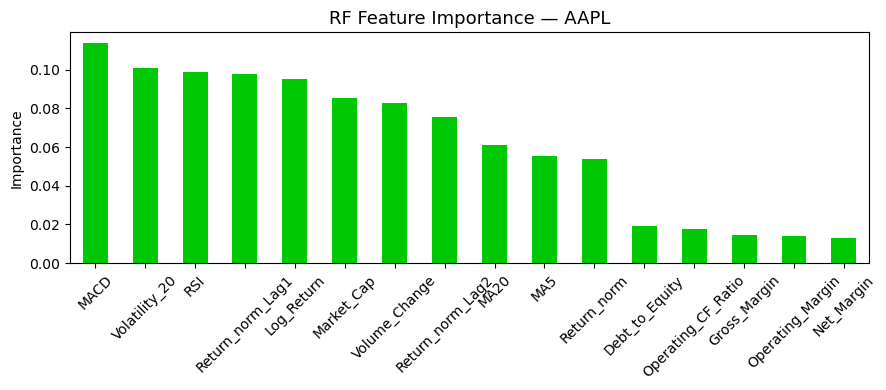


Top features:
MACD                0.113671
Volatility_20       0.101163
RSI                 0.098918
Return_norm_Lag1    0.097761
Log_Return          0.095389
Market_Cap          0.085603
Volume_Change       0.082793
Return_norm_Lag2    0.075736
MA20                0.061349
MA5                 0.055337


In [8]:
t0 = TICKERS[0]
df = dataframes[t0]
X_train, X_test, y_train, y_test = time_split(df, FEATURE_COLS, TARGET_COL)

rf_pipe = Pipeline([
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)

importances = rf_pipe.named_steps["reg"].feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
feat_imp.plot(kind="bar", ax=ax, color="#00c805")
ax.set_title(f"RF Feature Importance — {t0}", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

print("\nTop features:")
print(feat_imp.head(10).to_string())

## 8. Export pooled models

Based on the evaluation in sections 5–7, we now train the **final production models**
using a **pooled** approach — all tickers combined into one model per feature schema.

Two models are produced:

| Model file | Tickers | Features | Why |
|---|---|---|---|
| `model_pooled.pkl` | 25 standard tickers | 16 (price + vol-norm + fundamentals) | Full feature set available |
| `model_pooled_fallback.pkl` | BAC, GS, JPM, MA, V | 11 (price + vol-norm only) | Fundamental data structurally unavailable |

**Training strategy:**
- Per-ticker 80/20 temporal split applied **before** pooling — prevents the test set from being dominated by whichever tickers appear last alphabetically.
- Three models evaluated on the pooled test set (LR, RF, GBR); the one with the highest R² is selected.
- StandardScaler applied **only** to LinearRegression; tree-based models are scale-invariant.
- Winning model is re-trained on the **full dataset** (train + test) before saving — the split was only needed for fair evaluation.

The saved `.pkl` files are loaded directly by `app/pages/go_live.py` and `app/pages/backtesting.py`.
The production CLI equivalent is:  `python model/train.py --all`

In [9]:
# ── Feature schemas ────────────────────────────────────────────────────────────
# Mirrors model/strategy.py — both must stay in sync.

FALLBACK_TICKERS = {"BAC", "GS", "JPM", "MA", "V"}  # no fundamental data available

# Standard schema: all 16 features (price + vol-norm + fundamental)
STANDARD_FEATURE_COLS = FEATURE_COLS  # defined in section 1

# Fallback schema: 11 features (price + vol-norm only — no fundamentals)
FALLBACK_FEATURE_COLS = [
    "MA5", "MA20", "Volume_Change", "Market_Cap", "RSI", "MACD",
    "Log_Return", "Volatility_20", "Return_norm", "Return_norm_Lag1", "Return_norm_Lag2",
]


# ── Helpers ────────────────────────────────────────────────────────────────────

def split_ticker(df, feature_cols, target_col=TARGET_COL, train_ratio=0.80):
    """Drop NaN rows first, then apply an 80/20 temporal split.

    Returns (train_df, test_df) — full rows, not X/y slices, so the caller
    can pool multiple tickers before separating features from target.
    """
    clean = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
    idx = int(len(clean) * train_ratio)
    return clean.iloc[:idx], clean.iloc[idx:]


def train_pooled(tickers, feature_cols, model_filename, label):
    """Pool data from `tickers`, evaluate LR/RF/GBR, save best by test R².

    Steps:
      1. Per-ticker 80/20 temporal split (NaN dropped first per ticker).
      2. Concatenate all train frames and all test frames.
      3. Train all three model families on the pooled train set.
      4. Evaluate each on the pooled test set — select best by R².
      5. Re-train a fresh instance of the winner on ALL data (train + test).
      6. Save to model/trained/{model_filename}.
    """
    train_frames, test_frames, skipped = [], [], []

    for ticker in tickers:
        if ticker not in dataframes:
            skipped.append(ticker)
            continue
        tr, te = split_ticker(dataframes[ticker], feature_cols)
        if len(tr) < 10 or len(te) < 1:
            skipped.append(ticker)
            continue
        train_frames.append(tr)
        test_frames.append(te)

    if not train_frames:
        print(f"[{label}] No usable data — aborting.")
        return

    train_df = pd.concat(train_frames, ignore_index=True)
    test_df  = pd.concat(test_frames,  ignore_index=True)

    print(f"\n[{label}] Pooled: train={len(train_df):,} rows, test={len(test_df):,} rows")
    if skipped:
        print(f"[{label}] Skipped: {skipped}")

    X_train, y_train = train_df[feature_cols], train_df[TARGET_COL]
    X_test,  y_test  = test_df[feature_cols],  test_df[TARGET_COL]

    # ── Evaluate all three model families ─────────────────────────────────────
    candidates = build_pipelines()
    best_name, best_r2 = None, -float("inf")

    for name, pipe in candidates.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        r2  = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        print(f"  {name:<25s}  R²={r2:+.4f}  MAE={mae:.6f}")
        if r2 > best_r2:
            best_r2, best_name = r2, name

    print(f"  → Best: {best_name}  (R²={best_r2:+.4f})")

    # ── Re-train winner on full data, then save ────────────────────────────────
    all_df     = pd.concat(train_frames + test_frames, ignore_index=True)
    final_pipe = build_pipelines()[best_name]   # fresh instance — not the fitted one
    final_pipe.fit(all_df[feature_cols], all_df[TARGET_COL])

    path = os.path.join(TRAINED_DIR, model_filename)
    joblib.dump(final_pipe, path)
    print(f"  Saved → {path}")


# ── Run both pools ─────────────────────────────────────────────────────────────
TRAINED_DIR = "../model/trained"
os.makedirs(TRAINED_DIR, exist_ok=True)

standard_tickers = [t for t in TICKERS if t not in FALLBACK_TICKERS]
fallback_tickers  = [t for t in TICKERS if t in FALLBACK_TICKERS]

train_pooled(standard_tickers, STANDARD_FEATURE_COLS, "model_pooled.pkl",          "standard")
train_pooled(fallback_tickers,  FALLBACK_FEATURE_COLS, "model_pooled_fallback.pkl", "fallback")

print("\nDone. Two pooled models saved to model/trained/")
print("  model_pooled.pkl          — standard tickers (16 features)")
print("  model_pooled_fallback.pkl — fallback tickers (11 features, no fundamentals)")
print("\nProduction CLI:  python model/train.py --all")


[standard] Pooled: train=22,148 rows, test=5,548 rows
  LinearRegression           R²=-0.0026  MAE=0.015304
  RandomForest               R²=-0.0814  MAE=0.015959
  GradientBoosting           R²=-0.1623  MAE=0.016234
  → Best: LinearRegression  (R²=-0.0026)
  Saved → ../model/trained\model_pooled.pkl

[fallback] Pooled: train=4,860 rows, test=1,215 rows
  LinearRegression           R²=-0.0025  MAE=0.009961
  RandomForest               R²=-0.0669  MAE=0.010441
  GradientBoosting           R²=-0.0776  MAE=0.010461
  → Best: LinearRegression  (R²=-0.0025)
  Saved → ../model/trained\model_pooled_fallback.pkl

Done. Two pooled models saved to model/trained/
  model_pooled.pkl          — standard tickers (16 features)
  model_pooled_fallback.pkl — fallback tickers (11 features, no fundamentals)

Production CLI:  python model/train.py --all
